## Set Up

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind

In [2]:
scenarios_path = Path().resolve() / "../../scenarios_inputs" / "nie" 
annotated_output_path = Path().resolve() / "../../annotated_outputs" / "nie"

print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")

scenarios_path: /home/bhatto/graph_extract/analysis/nie/../../scenarios_inputs/nie
annotated_output_path: /home/bhatto/graph_extract/analysis/nie/../../annotated_outputs/nie


## Define Functions

In [3]:
def read_scenario(i): 

    file_path = annotated_output_path / f"nie_scenarios_{i}_choice_1.json"

    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]


    # also return original scenario text for reference
    with open(scenarios_path / "nie_scenarios.json") as f:
        scenario_list = json.load(f)
        #get the one with the matching id
        scenario_text = next(s['text'] for s in scenario_list if s['id'] == i)

    return nodes, scenario_text

In [4]:

def events_to_utility_df(nodes):
  
    util_dfs = []

    for node in nodes:
        n = node.get('node',{})
        if n.get('kind') == 'event':
            links = node.get('links')
            data = {}
            for link in links:
                to_node = link.get('to_node')
                value = link.get('link', {}).get('value')
                data[to_node] = value
                label = n.get('label')
                df = pd.DataFrame([data], index=[label])
            util_dfs.append(df)

    df = pd.concat(util_dfs, ignore_index=False)
    df = df.apply(pd.to_numeric)
    
    return df


In [5]:
#attempt for a generitc utility function to read the annotation files for a given annotation output json file.
def parse_events_with_labels(file_path):
    """
    Parse a JSON file containing event nodes and extract their C/I/K polarity labels.
    
    Args:
        file_path: Path to the JSON file
        
    Returns:
        dict: Mapping of event labels to their C/I/K polarity strings
              e.g., {"Historical buildings are demolished": "C+I+K+", ...}
    """
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # Parse each line to create a list of JSON objects
    nodes = [json.loads(line.strip()) for line in lines if line.strip()]
    
    # Find the first being node (first node with kind "being")
    being_node = None
    for node_obj in nodes:
        if node_obj.get('node', {}).get('kind') == 'being':
            being_node = node_obj
            break
    
    if not being_node:
        return {}
    
    # Create a mapping from event labels to their C/I/K values
    event_labels = {}
    
    for link in being_node.get('links', []):
        to_node_label = link.get('to_node')
        b_link_value = link.get('link', {}).get('value')
        
        if to_node_label and b_link_value:
            event_labels[to_node_label] = b_link_value
    
    # Filter to only include actual events
    event_nodes = {
        node_obj['node']['label'] 
        for node_obj in nodes 
        if node_obj.get('node', {}).get('kind') == 'event'
    }
    
    return {label: value for label, value in event_labels.items() if label in event_nodes}

## Utilities

In [6]:
#create a dataframe with utilities by entity and outcome
import pandas as pd
from IPython.display import display, HTML
nodes, text = read_scenario(0)
print(text)
util_df = events_to_utility_df(nodes)
display(HTML(util_df.to_html()))

 A high-speed train is about to hit a bus with 10 passengers. I, an employee of the train company, could redirect the train to a side track where a bus with 2 passengers is sitting.


,i,10 bus passengers on the current track,2 bus passengers on the side track
The train is redirected to the side track,0,90,-100
The train hits the bus on the side track,-15,85,-100
The 2 passengers on the side-track bus are killed,-85,100,-100
The 10 passengers on the original-track bus are not hit by the train,0,100,0
I prevent the deaths of 10 bus passengers,0,100,-100


In [7]:
#how does one aggregate the outcomes? 

#for each being, get the product of the positive utilites and the product of the negative utilities


In [8]:
from functools import reduce

# For each being (column), calculate product of positive and negative utilities across outcomes
utility_products = {}
for col in util_df.columns:
    positive_utils = util_df[col][util_df[col] > 0]
    negative_utils = util_df[col][util_df[col] < 0]
    pos_product = reduce(lambda x, y: x * y, positive_utils, 1) if not positive_utils.empty else 0
    neg_product = reduce(lambda x, y: x * y, negative_utils, 1) if not negative_utils.empty else 0
    utility_products[col] = {"positive_product": pos_product, "negative_product": neg_product, "difference": pos_product - neg_product}

# Display results
benefit_df = pd.DataFrame(utility_products)
benefit_df

,i,10 bus passengers on the current track,2 bus passengers on the side track
positive_product,0,7650000000,0
negative_product,1275,0,100000000
difference,-1275,7650000000,-100000000


In [9]:
util_mean_df = pd.DataFrame({'mean_utility': util_df.mean()})
util_mean_df

,mean_utility
i,-20.0
10 bus passengers on the current track,95.0
2 bus passengers on the side track,-80.0


In [10]:
#correlate mean_utility from util_mean_df with the difference row of the benefit_df
correlation = util_mean_df['mean_utility'].corr(benefit_df.loc['difference'])
print(f"Correlation between mean utility and difference in products: {correlation}")

Correlation between mean utility and difference in products: 0.9451142003509048


## Self vs Other Benefit 

Compare "Beneficiary" Labels in the Experiment with Utility scores from the annotator

In [11]:
sid_record = []
scenario_benefit_labels = []
annotator_benefit_labels = []
annotator_self_benefit = []
annotator_other_benefit = []

match_count = 0
fail_match_count = 0
scenario_count = 0
fail_match_diffs = []

with open(scenarios_path / "nie_scenarios.json") as f:
    scenario_list = json.load(f)

for i in range(0, 62):  # For all 62 scenarios
    scenario_factors = [scenario_dict["factors"]["1"] for scenario_dict in scenario_list if scenario_dict["id"] == i][0]  # Extract dictionary of factors

    if scenario_factors == {} or "Locus Of Intervention" in scenario_factors.keys():
        continue  # Only using entries with "Causal Role", "Beneficiary", "Evitability", and "Personal Force"
    else:
        scenario_benefit = scenario_factors["Beneficiary"]  # Either "Self-beneficial" or "Other-beneficial"
    
    self_benefit = 0
    other_benefit = 0
    outcome_count = 0

    with open(annotated_output_path / f"nie_scenarios_{i}_choice_1.json") as annotator_file:
        for line in annotator_file:
            annotator_dict = json.loads(line)

            this_self_benefit = 0
            this_self_adjust_num = 0
            this_other_benefit = 0
            this_other_adjust_num = 0

            links_list = annotator_dict["links"]
            if links_list == [] or links_list[0]["link"]["kind"] != "utility":
                continue
            else:
                for link_dict in links_list:
                    if link_dict["link"]["kind"] == "utility":
                        if link_dict["to_node"] == "I":
                            this_self_benefit += int(link_dict["link"]["value"])
                            this_self_adjust_num += 1
                        else:
                            this_other_benefit += int(link_dict["link"]["value"])
                            this_other_adjust_num += 1
                        outcome_count += 1
            
            # Calculating average benefit for each outcome
            # self_benefit += this_self_benefit / this_self_adjust_num if this_self_adjust_num != 0 else 0
            # other_benefit += this_other_benefit / this_other_adjust_num if this_other_adjust_num != 0 else 0

            # calculate sum of benefits across entities 
            self_benefit += this_self_benefit
            other_benefit += this_other_benefit
        
    # Calculating average benefit across outcomes
    # self_benefit = self_benefit / outcome_count if outcome_count != 0 else 0
    # other_benefit = other_benefit / outcome_count if outcome_count != 0 else 0

    #calculating the sum of benefits across outcomes
    # self_benefit = self_benefit / outcome_count if outcome_count != 0 else 0
    # other_benefit = other

    annotator_self_benefit.append(self_benefit)
    annotator_other_benefit.append(other_benefit)

    # Setting overall benefit based on calculated average
    annotator_benefit = "Self-beneficial" if self_benefit >= other_benefit else "Other-beneficial"

    scenario_benefit_labels.append(scenario_benefit)
    annotator_benefit_labels.append(annotator_benefit)

    if annotator_benefit == scenario_benefit:
        match_count += 1
    else:
        fail_match_count += 1
        fail_match_diffs.append(self_benefit - other_benefit)
    scenario_count += 1
    sid_record.append(i)

benefit_utility_df = pd.DataFrame({"SID": sid_record,
                                   "Scenario Benefit": scenario_benefit_labels, 
                                   "Annotator Benefit": annotator_benefit_labels,
                                   "Self-benefit (from annotator)": annotator_self_benefit, 
                                   "Other-benefit (from annotator)": annotator_other_benefit,
                                   "Difference (Self-benefit - Other-benefit)": list(np.subtract(np.array(annotator_self_benefit), np.array(annotator_other_benefit)))})

print(f"Total scenarios checked: {scenario_count}")
print(f"Matched scenarios: {match_count} (proportion out of total: {match_count / scenario_count if scenario_count != 0 else 0:.3f})")
print(f"Scenarios that failed to match: {fail_match_count} (proportion out of total: {fail_match_count / scenario_count if scenario_count != 0 else 0:.3f})")
print(f"Differences in Utility for Failed Matches (Self-benefit - Other-benefit):\n{fail_match_diffs}\n")

print(benefit_utility_df.to_string())

KeyError: 'links'

In [ ]:
#use pandas to get the mean and sd of self-benefit for each Scenario Benefit type
mean_sd_df = benefit_utility_df.groupby("Scenario Benefit")["Self-benefit (from annotator)"].agg(['mean', 'std']).reset_index()
print("\nMean and Standard Deviation of Self-benefit by Scenario Benefit Type:")
print(mean_sd_df.to_string())


Mean and Standard Deviation of Self-benefit by Scenario Benefit Type:
   Scenario Benefit        mean         std
0  Other-beneficial -153.846154  191.019935
1   Self-beneficial -106.363636  253.293458


In [ ]:
#use pandas to get the mean and sd of other-benefit for each Scenario Benefit type
mean_sd_df = benefit_utility_df.groupby("Scenario Benefit")["Other-benefit (from annotator)"].agg(['mean', 'std']).reset_index()
print("\nMean and Standard Deviation of Other-benefit by Scenario Benefit Type:")
print(mean_sd_df.to_string())


Mean and Standard Deviation of Other-benefit by Scenario Benefit Type:
   Scenario Benefit        mean          std
0  Other-beneficial  161.730769  1066.659217
1   Self-beneficial  -11.272727  1569.934005


/var/folders/4g/x09k0pjs3lv174fn9g0511840000gn/T/ipykernel_35959/377147260.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(data=plot_df, x="Scenario Benefit", y="Benefit Value", hue="Benefit Type", ci=68, capsize=0.1, alpha=0.7, errwidth=1.5, palette=palette)
/var/folders/4g/x09k0pjs3lv174fn9g0511840000gn/T/ipykernel_35959/377147260.py:13: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  sns.barplot(data=plot_df, x="Scenario Benefit", y="Benefit Value", hue="Benefit Type", ci=68, capsize=0.1, alpha=0.7, errwidth=1.5, palette=palette)
/var/folders/4g/x09k0pjs3lv174fn9g0511840000gn/T/ipykernel_35959/377147260.py:15: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=plot_df, x="Scenario Benefit", y="Benefit Value", hue="Benefit Type", dodge=

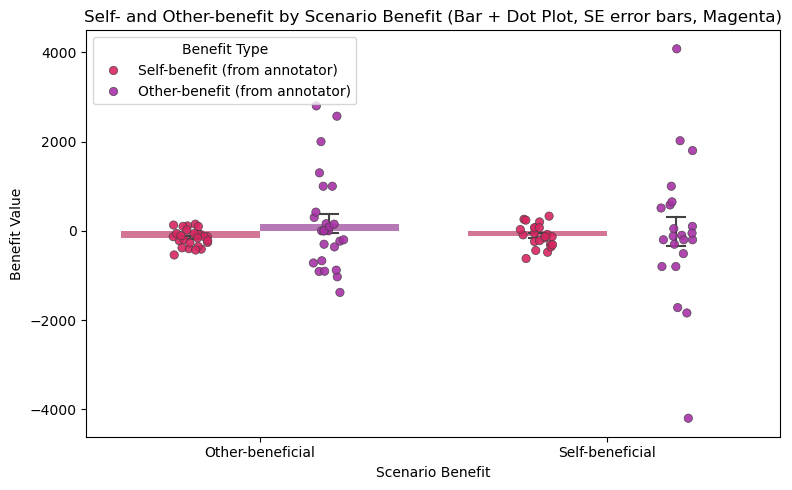

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for plotting
plot_df = benefit_utility_df.melt(id_vars=["SID", "Scenario Benefit"], 
                                  value_vars=["Self-benefit (from annotator)", "Other-benefit (from annotator)"],
                                  var_name="Benefit Type", value_name="Benefit Value")

plt.figure(figsize=(8, 5))
# Custom magenta palette
palette = ["#d72660", "#a832a6"]  # Two shades of magenta/purple
# Bar plot (mean with standard error bars)
sns.barplot(data=plot_df, x="Scenario Benefit", y="Benefit Value", hue="Benefit Type", ci=68, capsize=0.1, alpha=0.7, errwidth=1.5, palette=palette)
# Dot plot overlaid
sns.stripplot(data=plot_df, x="Scenario Benefit", y="Benefit Value", hue="Benefit Type", dodge=True, jitter=True, size=6, marker="o", edgecolor="gray", linewidth=0.5, alpha=0.9, palette=palette)
plt.title("Self- and Other-benefit by Scenario Benefit (Bar + Dot Plot, SE error bars, Magenta)")
plt.ylabel("Benefit Value")
plt.xlabel("Scenario Benefit")
# Remove duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Benefit Type")
plt.tight_layout()
plt.show()

## Causality and Intentionality

Extract C/I/K Labels

#### first, process all outcome CIK links

In [ ]:
with open(scenarios_path / "nie_scenarios.json") as f:
    scenario_list = json.load(f)

sids = []
causal_labels = []
benefit_labels = []
evitable_labels = []
force_labels = []
Cs = []
Is = []
Ks = []
outcome_descs = []

for i in range(0, len(scenario_list)):  # For all scenarios we have in the scenarios list
    scenario_factors = [scenario_dict["factors"]["1"] for scenario_dict in scenario_list if scenario_dict["id"] == i][0]  # Extract dictionary of factors

    if scenario_factors == {} or "Locus Of Intervention" in scenario_factors.keys():
        continue  # Only using entries with "Causal Role", "Beneficiary", "Evitability", and "Personal Force"
    
    with open(annotated_output_path / f"nie_scenarios_{i}_choice_1.json") as annotator_file:
        for line in annotator_file:
            annotator_dict = json.loads(line)

            links_list = annotator_dict["links"]
            if links_list == [] or links_list[0]["link"]["kind"] != "b-link":  # Note: Only the first is b-link, rest are b_link
                continue
            else:
                for link_dict in links_list:
                    sids.append(i)
                    causal_labels.append(scenario_factors["Causal Role"])
                    benefit_labels.append(scenario_factors["Beneficiary"])
                    evitable_labels.append(scenario_factors["Evitability"])
                    force_labels.append(scenario_factors["Personal Force"])
                    Cs.append(link_dict["link"]["value"][1])
                    Is.append(link_dict["link"]["value"][3])
                    Ks.append(link_dict["link"]["value"][-1])
                    outcome_descs.append(link_dict["to_node"])

CIK_labels_df = pd.DataFrame({
    "SID": sids,
    "Causal Role": causal_labels,
    "Beneficiary": benefit_labels,
    "Evitability": evitable_labels,
    "Personal Force": force_labels,
    "C": Cs,
    "I": Is,
    "K": Ks,
    "Outcome": outcome_descs  # Note: Original action choices begin in lowercase. Generated outcomes begin in uppercase.
})

# print(CIK_labels_df.to_string())

In [ ]:
# CIK_labels_df

In [ ]:
CIK_labels_df[CIK_labels_df["SID"]==21]

,SID,Causal Role,Beneficiary,Evitability,Personal Force,C,I,K,Outcome
56,21,Side Effect,Self-beneficial,Avoidable,Impersonal,+,+,+,push the button to open the hatch that will fa...
57,21,Side Effect,Self-beneficial,Avoidable,Impersonal,+,+,+,The hatch falls on the unconscious crewmember ...
58,21,Side Effect,Self-beneficial,Avoidable,Impersonal,+,+,+,Oxygen from the lower section becomes accessib...


#### Second, select the 'primary harm' inferred to be intended by the designers of the study


Note that this analysis is highly specific to an annotator run and version given that we are tagging specific outcomes as the "primary harm" intended by the experimentors. 

In [ ]:
harm_idx = [2, 10, 17, 29, 38, 44, 52, 57, 60, 68, 76, 82, 89, 98,
            106, 113, 124, 135, 139, 150, 153, 159, 167, 173, 182, 188,
            197, 205, 215, 220, 228, 235, 240, 247, 254, 262, 267, 278,
            280, 288, 293, 300, 312, 317, 322, 332, 343, 353]  # Chosen by hand

primary_harm_df = CIK_labels_df.iloc[harm_idx]

print(primary_harm_df[["SID", "Causal Role", "C", "I", "K", "Outcome"]].to_string())

     SID  Causal Role  C  I  K                                                                                  Outcome
2     10        Means  +  +  +                                                   The heavy worker falls onto the tracks
10    11        Means  +  +  +                                                   The heavy worker falls onto the tracks
17    16        Means  +  +  +                                             The injured person experiences physical harm
29    17  Side Effect  +  +  +                                                   The injured person is left without air
38    18  Side Effect  +  -  +                                                           The baby dies from suffocation
44    19  Side Effect  +  +  +                                                         The baby is asphyxiated and dies
52    20  Side Effect  +  -  +                     The unconscious crewmember is physically harmed by the falling hatch
57    21  Side Effect  +  +  +          

### Third, convert to numeric form & summarize

In [ ]:
# Map "+" to 1 and "-" to -1 for C, I, K columns
primary_harm_numeric = primary_harm_df.copy()
for col in ["C", "I", "K"]:
	primary_harm_numeric[col] = primary_harm_numeric[col].map({"+": 1, "-": -1})

# Create summary table of C, I, K values for the Causal Role and Evitability factors 
summary_CIK_df = primary_harm_numeric.groupby(["Causal Role", "Evitability"])[["C", "I", "K"]].agg(['mean', 'sem']).reset_index()
print("\nSummary Table of C, I, K values by Causal Role and Evitability:")
# print(primary_harm_numeric)
print(summary_CIK_df.to_string())


Summary Table of C, I, K values by Causal Role and Evitability:
   Causal Role Evitability    C              I                   K          
                           mean  sem      mean       sem      mean       sem
0        Means   Avoidable  1.0  0.0  1.000000  0.000000  1.000000  0.000000
1        Means  Inevitable  1.0  0.0  0.578947  0.192183  0.894737  0.105263
2  Side Effect   Avoidable  1.0  0.0 -0.200000  0.326599  0.600000  0.266667
3  Side Effect  Inevitable  1.0  0.0 -0.142857  0.404061  1.000000  0.000000


In [ ]:
summary_CIK_df_2 = primary_harm_numeric.groupby(["Causal Role"])[["C", "I", "K"]].agg(['mean', 'sem']).reset_index()
print("\nSummary Table of C, I, K values by Causal Role and Evitability:")
# print(primary_harm_numeric)
print(summary_CIK_df_2.to_string())


Summary Table of C, I, K values by Causal Role and Evitability:
   Causal Role    C              I                   K          
               mean  sem      mean       sem      mean       sem
0        Means  1.0  0.0  0.741935  0.122411  0.935484  0.064516
1  Side Effect  1.0  0.0 -0.176471  0.246076  0.764706  0.161095


/var/folders/4g/x09k0pjs3lv174fn9g0511840000gn/T/ipykernel_35959/2297910762.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(data=primary_harm_numeric, x="Causal Role", y="I", ci=68, capsize=0.1, palette=["#d72660", "#a832a6"])
/var/folders/4g/x09k0pjs3lv174fn9g0511840000gn/T/ipykernel_35959/2297910762.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=primary_harm_numeric, x="Causal Role", y="I", ci=68, capsize=0.1, palette=["#d72660", "#a832a6"])


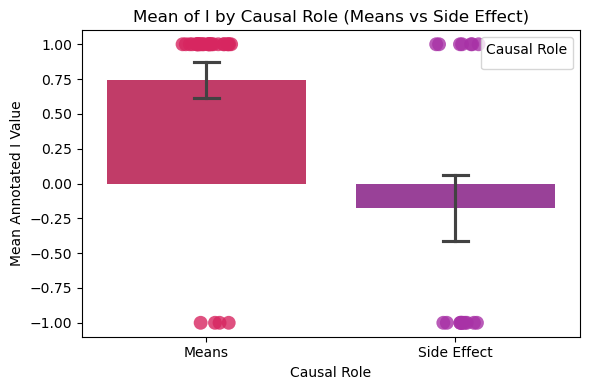

In [ ]:
#create a plot to summarize

plt.figure(figsize=(6, 4))
# Bar plot with magenta palette
sns.barplot(data=primary_harm_numeric, x="Causal Role", y="I", ci=68, capsize=0.1, palette=["#d72660", "#a832a6"])
# Dot plot: color by Causal Role, larger dots
sns.stripplot(data=primary_harm_numeric, x="Causal Role", y="I", hue="Causal Role", dodge=False, jitter=True, size=10, alpha=0.8, palette=["#d72660", "#a832a6"])
plt.title("Mean of I by Causal Role (Means vs Side Effect)")
plt.ylabel("Mean Annotated I Value")
plt.xlabel("Causal Role")
# Remove duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Causal Role")
plt.tight_layout()
plt.show()

What seems to be happening is that there is a split between these scenarios. Let's output the outcomes that were given -1 and +1 for I to see what is happening in each category.

In [ ]:
# For Causal Role == "Means"
means_I_pos = primary_harm_numeric[(primary_harm_numeric["Causal Role"] == "Means") & (primary_harm_numeric["I"] == 1)]
means_I_neg = primary_harm_numeric[(primary_harm_numeric["Causal Role"] == "Means") & (primary_harm_numeric["I"] == -1)]

means_I_pos_list = means_I_pos.to_dict('records')
means_I_neg_list = means_I_neg.to_dict('records')

# For Causal Role == "Side Effect"
sideeffect_I_pos = primary_harm_numeric[(primary_harm_numeric["Causal Role"] == "Side Effect") & (primary_harm_numeric["I"] == 1)]
sideeffect_I_neg = primary_harm_numeric[(primary_harm_numeric["Causal Role"] == "Side Effect") & (primary_harm_numeric["I"] == -1)]

sideeffect_I_pos_list = sideeffect_I_pos.to_dict('records')
sideeffect_I_neg_list = sideeffect_I_neg.to_dict('records')


In [ ]:
sideeffect_I_pos

,SID,Causal Role,Beneficiary,Evitability,Personal Force,C,I,K,Outcome
29,17,Side Effect,Self-beneficial,Avoidable,Impersonal,1,1,1,The injured person is left without air
44,19,Side Effect,Self-beneficial,Avoidable,Impersonal,1,1,1,The baby is asphyxiated and dies
57,21,Side Effect,Self-beneficial,Avoidable,Impersonal,1,1,1,The hatch falls on the unconscious crewmember ...
167,36,Side Effect,Self-beneficial,Inevitable,Personal,1,1,1,The third child drowns
205,41,Side Effect,Other-beneficial,Avoidable,Impersonal,1,1,1,The container drops onto one crewmember in the...
288,53,Side Effect,Other-beneficial,Inevitable,Impersonal,1,1,1,The one patient in the second room is killed b...
300,55,Side Effect,Other-beneficial,Inevitable,Impersonal,1,1,1,The third child remains in danger of freezing ...
322,58,Side Effect,Other-beneficial,Inevitable,Personal,1,1,1,The wealthy tycoon dies sooner than expected


In [ ]:
means_I_neg

,SID,Causal Role,Beneficiary,Evitability,Personal Force,C,I,K,Outcome
262,49,Means,Other-beneficial,Inevitable,Impersonal,1,-1,1,The falling biker may experience additional im...
293,54,Means,Other-beneficial,Inevitable,Personal,1,-1,1,The heavy child experiences distress and poten...
312,56,Means,Other-beneficial,Inevitable,Personal,1,-1,1,The miner in the knocked-over cubicle may expe...
317,57,Means,Other-beneficial,Inevitable,Impersonal,1,-1,-1,The miners in the last cubicle are injured or ...


In [ ]:
means_I_neg["Outcome"].iloc[1]

'The heavy child experiences distress and potential harm'

In [ ]:
#what we are
primary_harm_numeric

### Deontology

Extract Annotator Deontology Ratings

In [ ]:
action_choice_info = CIK_labels_df[CIK_labels_df["SID"] != CIK_labels_df["SID"].shift()]  # First outcome per scenario

sids = []
force_labels = []
values = []
actions = []

for i in range(0, 62):
    if i not in CIK_labels_df["SID"].values:
        continue

    with open(annotated_output_path / f"nie_scenarios_{i}_choice_1.json") as annotator_file:
        for line in annotator_file:
            annotator_dict = json.loads(line)

            if annotator_dict["node"]["kind"] == "action_choice":
                action = annotator_dict["node"]["label"]
                actions.append(action)
                for link in annotator_dict["links"]:
                    if link["to_node"] == "value":
                        values.append(int(link["link"]["value"]))
    sids.append(i)
    force_labels.append(action_choice_info.loc[action_choice_info["Outcome"] == action, "Personal Force"].iloc[0])

force_deont_df = pd.DataFrame({
    "SID": sids,
    "Personal Force": force_labels,
    "Annotator Rating": values,
    "Action Choice": actions
})

print(force_deont_df.to_string())

    SID Personal Force  Annotator Rating                                                                                                       Action Choice
0    10       Personal               -95                                                                                     push the worker from the bridge
1    11     Impersonal                 0                                                                                                     push the button
2    16       Personal               -80                                                                   use the injured person to break down the blockage
3    17     Impersonal               -80                                 activate the emergency system to put out the fire and leave the injured without air
4    18       Personal              -100                                put a hand over the baby's mouth to absorb the crying and leave the baby without air
5    19     Impersonal              -100                  

Compare "Personal Force" with Annotator Deontology Ratings

In [ ]:
personal_ratings = force_deont_df[force_deont_df['Personal Force'] == 'Personal']['Annotator Rating']
impersonal_ratings = force_deont_df[force_deont_df['Personal Force'] == 'Impersonal']['Annotator Rating']

print(f"Average Rating for Personal: {personal_ratings.mean():.4f}")
print(f"Average Rating for Impersonal: {impersonal_ratings.mean():.4f}")

force_tstat, force_pval = ttest_ind(personal_ratings, impersonal_ratings)
print(f"t-statistic: {force_tstat:.4f}, p-value: {force_pval:.4f}")

Average Rating for Personal: -82.7083
Average Rating for Impersonal: -66.4583
t-statistic: -1.5130, p-value: 0.1371


Table for "Causal Role" and C+/C- I+/I- Labels (Across Outcomes)

In [ ]:
unique_sids = pd.unique(CIK_labels_df["SID"])
cr_labels = []
C_plus_proportions = []
I_plus_proportions = []

for sid in unique_sids:
    current_scenario = CIK_labels_df[CIK_labels_df["SID"] == sid]
    cr_labels.append(current_scenario["Causal Role"].iloc[0])
    C_plus_proportions.append(current_scenario["C"].value_counts().get("+", 0) / len(current_scenario["C"]))
    I_plus_proportions.append(current_scenario["I"].value_counts().get("+", 0) / len(current_scenario["I"]))

cr_table = pd.DataFrame({
    "SID": unique_sids,
    "Causal Role": cr_labels,
    "C+": C_plus_proportions,
    "I+": I_plus_proportions
})

print(cr_table.to_string())

print(f"Average C+ for Means: {cr_table[cr_table['Causal Role'] == 'Means']['C+'].mean()}")
print(f"Average C+ for Side Effect: {cr_table[cr_table['Causal Role'] == 'Side Effect']['C+'].mean()}")
print(f"Average I+ for Means: {cr_table[cr_table['Causal Role'] == 'Means']['I+'].mean()}")
print(f"Average I+ for Side Effect: {cr_table[cr_table['Causal Role'] == 'Side Effect']['I+'].mean()}")

    SID  Causal Role        C+        I+
0    10        Means  1.000000  1.000000
1    11        Means  1.000000  1.000000
2    16        Means  1.000000  0.625000
3    17  Side Effect  1.000000  0.714286
4    18  Side Effect  1.000000  0.600000
5    19  Side Effect  1.000000  0.888889
6    20  Side Effect  1.000000  0.833333
7    21  Side Effect  1.000000  1.000000
8    22        Means  1.000000  0.750000
9    23        Means  1.000000  0.500000
10   24        Means  1.000000  0.666667
11   25        Means  1.000000  0.714286
12   26        Means  1.000000  0.555556
13   27        Means  1.000000  0.750000
14   28        Means  1.000000  1.000000
15   29        Means  1.000000  0.625000
16   30  Side Effect  1.000000  0.666667
17   31  Side Effect  1.000000  0.777778
18   32        Means  1.000000  0.875000
19   33  Side Effect  1.000000  0.833333
20   34        Means  1.000000  1.000000
21   35        Means  1.000000  1.000000
22   36  Side Effect  1.000000  0.833333
23   37  Side Ef

Compare "Causal Role" ("Means"/"Side Effect") with C+/C-

In [ ]:
causal_vs_C_table = pd.crosstab(CIK_labels_df["Causal Role"], CIK_labels_df["C"], margins=True, normalize=True)
print(causal_vs_C_table)

chi2, p, dof, expected = chi2_contingency(causal_vs_C_table)
print(f"\nChi-Squared Statistic: {chi2}\np-value: {p}\nDegrees of Freedom: {dof}\nExpected Frequencies: \n{expected}")

C                   +        -       All
Causal Role                             
Means        0.631579  0.00554  0.637119
Side Effect  0.360111  0.00277  0.362881
All          0.991690  0.00831  1.000000

Chi-Squared Statistic: 3.164437654088647e-05
p-value: 0.9999999998748305
Degrees of Freedom: 4
Expected Frequencies: 
[[0.63182449 0.00529462 0.63711911]
 [0.35986526 0.00301563 0.36288089]
 [0.99168975 0.00831025 1.        ]]


In [ ]:
unique_sids = pd.unique(CIK_labels_df["SID"])

condition_count = {}
means_count = 0
side_effect_count = 0

for sid in unique_sids:
    causal_role_labels = CIK_labels_df[CIK_labels_df["SID"] == sid]["Causal Role"]
    C_labels = CIK_labels_df[CIK_labels_df["SID"] == sid]["C"]
    means_count += len([label for label in causal_role_labels if label == "Means"])
    side_effect_count += len([label for label in causal_role_labels if label == "Side Effect"])

    packaged_labels = zip(causal_role_labels, C_labels)

    for package in packaged_labels:
        if package not in condition_count.keys():
            condition_count[package] = 1
        else:
            condition_count[package] += 1

print(f"Total Count of Means: {means_count}\nTotal Count of Side Effects: {side_effect_count}")
print(condition_count)

Total Count of Means: 230
Total Count of Side Effects: 131
{('Means', '+'): 228, ('Side Effect', '+'): 130, ('Side Effect', '-'): 1, ('Means', '-'): 2}


Compare "Causal Role" ("Means"/"Side Effect") with I+/I-

In [ ]:
causal_vs_I_table = pd.crosstab(CIK_labels_df["Causal Role"], CIK_labels_df["I"], margins=True, normalize=True)
print(causal_vs_I_table)

chi2, p, dof, expected = chi2_contingency(causal_vs_I_table)
print(f"\nChi-Squared Statistic: {chi2}\np-value: {p}\nDegrees of Freedom: {dof}\nExpected Frequencies: \n{expected}")

I                   +         -       All
Causal Role                              
Means        0.470914  0.166205  0.637119
Side Effect  0.260388  0.102493  0.362881
All          0.731302  0.268698  1.000000

Chi-Squared Statistic: 0.0005475854759542961
p-value: 0.999999962525609
Degrees of Freedom: 4
Expected Frequencies: 
[[0.46592644 0.17119267 0.63711911]
 [0.2653755  0.09750539 0.36288089]
 [0.73130194 0.26869806 1.        ]]


In [ ]:
unique_sids = pd.unique(CIK_labels_df["SID"])

condition_count = {}
means_count = 0
side_effect_count = 0

for sid in unique_sids:
    causal_role_labels = CIK_labels_df[CIK_labels_df["SID"] == sid]["Causal Role"]
    I_labels = CIK_labels_df[CIK_labels_df["SID"] == sid]["I"]
    means_count += len([label for label in causal_role_labels if label == "Means"])
    side_effect_count += len([label for label in causal_role_labels if label == "Side Effect"])

    packaged_labels = zip(causal_role_labels, I_labels)

    for package in packaged_labels:
        if package not in condition_count.keys():
            condition_count[package] = 1
        else:
            condition_count[package] += 1

print(f"Total Count of Means: {means_count}\nTotal Count of Side Effects: {side_effect_count}")
print(condition_count)

Total Count of Means: 230
Total Count of Side Effects: 131
{('Means', '+'): 170, ('Means', '-'): 60, ('Side Effect', '+'): 94, ('Side Effect', '-'): 37}


Overall Glance at Possible Mappings

In [ ]:
def chi_square_assoc(df, col1, col2):
    """
    Compute Chi-squared test and Cramér's V for two categorical columns.
    """
    table = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(table)

    # Cramér's V
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    cramers_v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

    return {
        "col1": col1,
        "col2": col2,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "cramers_v": cramers_v
    }

def categorical_assoc_matrix(df, cols):
    """
    Compute Cramér's V for all pairs of categorical columns.
    Returns a DataFrame like a correlation matrix.
    """
    matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)
    
    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):
            if i == j:
                matrix.loc[col1, col2] = 1.0
            elif pd.isna(matrix.loc[col1, col2]):
                res = chi_square_assoc(df, col1, col2)
                matrix.loc[col1, col2] = res["cramers_v"]
                matrix.loc[col2, col1] = res["cramers_v"]
    
    return matrix

                Causal Role  Beneficiary  Evitability  Personal Force         C         I         K
Causal Role        1.000000      0.12984     0.127158        0.126859  0.000000  0.000000  0.037228
Beneficiary        0.129840      1.00000     0.000000        0.000000  0.000000  0.000000  0.000000
Evitability        0.127158      0.00000     1.000000        0.000000  0.000000  0.000000  0.000000
Personal Force     0.126859      0.00000     0.000000        1.000000  0.000000  0.000000  0.000000
C                  0.000000      0.00000     0.000000        0.000000  1.000000  0.104156  0.056698
I                  0.000000      0.00000     0.000000        0.000000  0.104156  1.000000  0.012005
K                  0.037228      0.00000     0.000000        0.000000  0.056698  0.012005  1.000000


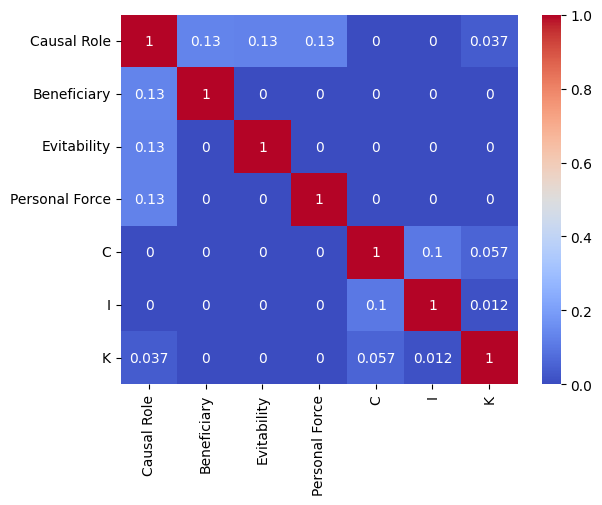

In [ ]:
assoc_matrix = categorical_assoc_matrix(CIK_labels_df, ["Causal Role", "Beneficiary", "Evitability", "Personal Force", "C", "I", "K"])

print(assoc_matrix.to_string())

sns.heatmap(assoc_matrix.astype(float), annot=True, cmap="coolwarm")
plt.show()
